**Author**:
- Tianci Wang - [tiancwang@ethz.ch](tianci:tiancwang@ethz.ch)

**Date**: 2025-05-21

# Policy Optimization Experiment Code v1.0
This code is used to perform policy optimization after obtaining the scores of all policies with different intensity levels using the PROMETHEE II method.
## Input data
1. Policy IDs, MCDA ranking scores, and the corresponding supported technologies;
2. Relative technology support level needs in the MIX, REMIX, and H2 scenarios compared with the baseline scenario Swiss Energy Perspectives 2050+ (EP2050+).
## Workflow
The code consists of four main steps:
1. Data preparation:

   Shift the MCDA scores to create a non-negative dataset for the technology support level calculation, and assign scores to each technology based on the technology support ratio.
2. Technology support level calculation:

   Calculate the technology support levels for the EP2050+ scenario and derive the corresponding support levels for the MIX, REMIX, and H2 scenarios.
3. Policy optimization:

   Optimize the policy selection for the MIX, REMIX, and H2 scenarios by minimizing costs while considering policy incompatibilities.
4. Result visualization:

   Generate the final plots to present the optimized policy portfolio results.
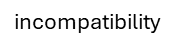

## 0 Import libraries and data

In [14]:
# Import Libraries
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
import seaborn as sns

# Import data
from config import POLICY_TABLE, SCENARIO_TABLE
df_policies = pd.read_csv(POLICY_TABLE)
df_scenarios = pd.read_csv(SCENARIO_TABLE)


## 1 Data preparation:
Shift the MCDA scores to create a non-negative dataset for the technology support level calculation, and assign scores to each technology based on the technology support ratio.
### 1.1 Non-Negative Score Shifting
To prevent negative resource distribution during the downstream optimization phases, the raw PROMETHEE II Net Flow ($\Phi$) scores are converted into a strictly non-negative dataset.

This is achieved by locating the absolute global minimum Net Flow score across all policy alternatives and applying a uniform upward translation shift ($+\lvert \Phi_{min} \rvert + 0.01$).

This preserves the absolute ordinal distance and performance variance between policy intensities while anchoring the baseline minimum score slightly above zero.

In [16]:
# Create a clean working copy of the policy dataframe
df_policies_clean = df_policies.copy()

# Find the global minimum value in the Net Flow column
min_net_flow = df_policies_clean['Net_Flow'].min()

print(f"--- Step 1.1 Execution ---")
print(f"Minimum Net Flow discovered in dataset: {min_net_flow:.4f}")

# Execute the transformation shift if negative values exist
if min_net_flow <= 0:
    shift_constant = abs(min_net_flow) + 0.01
    df_policies_clean['Shifted_Score'] = df_policies_clean['Net_Flow'] + shift_constant
    print(f"Action: Shifted all scores by adding a constant of {shift_constant:.4f}")
else:
    df_policies_clean['Shifted_Score'] = df_policies_clean['Net_Flow']
    print("Action: No shift required. All scores are already non-negative.")

# Preview the top entries to verify the conversion
print(df_policies_clean[['Policy_ID', 'Net_Flow', 'Shifted_Score']].head())

--- Step 1.1 Execution ---
Minimum Net Flow discovered in dataset: -0.4892
Action: Shifted all scores by adding a constant of 0.4992
  Policy_ID  Net_Flow  Shifted_Score
0    I_01_4  0.137634       0.636882
1    I_01_5  0.137634       0.636882
2    I_01_3  0.067742       0.566989
3    I_01_2 -0.022581       0.476667
4    I_01_1 -0.027957       0.471290
